# Tasks for laboratory assignment 2

In [8]:
# imports section

import pandas as pd
import numpy as np
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from autocorrect import Speller
import nltk
from wordcloud import WordCloud

import gensim as gs
from gensim.test.utils import lee_corpus_list
from gensim.models import Word2Vec
import gensim.downloader as api

import matplotlib.pyplot as plt

# Download the necessary resources
nltk.download('punkt')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\eu_an\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\eu_an\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Extract data from the json file 

Write a script, that would extract all the the data from the json file and return it in a list of texts for further use in the next tasks

## Extract data from the json file 

Write a script, that would extract all the the data from the json file and return it in a list of texts for further use in the next tasks

In [10]:
import json

def extract_texts_from_file(file_path):
    def extract_texts(obj):
        texts = []
        if isinstance(obj, dict):
            for value in obj.values():
                texts.extend(extract_texts(value))
        elif isinstance(obj, list):
            for item in obj:
                texts.extend(extract_texts(item))
        elif isinstance(obj, str):
            texts.append(obj)
        # Ignore other types (numbers, None, bool)
        return texts

    # Load JSON data from file
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Extract all texts recursively
    return extract_texts(data)


# Call the function and print the result
texts = extract_texts_from_file('resources/data.json')
print(texts)


['Oppenheimer, directed by Christopher Nolan, delves into the life of J. Robert Oppenheimer, the theoretical physicist who led the development of the atomic bomb. The film explores his moral and emotional struggles.', "Oppenheimer captures the life of the 'father of the atomic bomb' and his internal conflict after the success of the Manhattan Project. The film's complex narrative reflects on the cost of scientific achievement.", 'In Oppenheimer, Cillian Murphy delivers a riveting performance as the conflicted physicist who grapples with the consequences of his groundbreaking work on the atomic bomb, under the weight of global politics and ethics.', 'Oppenheimer is a cinematic exploration of ambition, guilt, and responsibility. Through stunning visuals and a thought-provoking story, Nolan brings the life of the brilliant but haunted physicist to the big screen.', 'Ducks are versatile waterfowl, known for their adaptability in freshwater and coastal habitats. With webbed feet and waterpr

## Process the texts

Write a script, that would process these texts. Processing should include:

- Lowercasing
- Removing Punctuation
- Removing Special Characters and Numbers
- Stemming or Lemmatization
- Handling Abbreviations
- Spelling Correction

In [12]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from autocorrect import Speller

# Initialize lemmatizer and spell checker
lemmatizer = WordNetLemmatizer()
spell = Speller(lang='en')

# Example abbreviation dictionary
abbreviations = {
    "can't": "cannot",
    "won't": "will not",
    "i'm": "i am",
    "it's": "it is",
    "don't": "do not",
    "you're": "you are",
}

def process_texts(texts):
    
    processed_texts = []

    for text in texts:
        # 1. Lowercase
        text = text.lower()

        # 2. Replace abbreviations
        for abbr, full in abbreviations.items():
            text = text.replace(abbr, full)

        # 3. Remove punctuation and special characters
        text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)  # keep only letters and spaces
        text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces

        # 4. Tokenize
        words = word_tokenize(text)

        # 5. Spelling correction and lemmatization
        words = [lemmatizer.lemmatize(spell(word)) for word in words]

        # 6. Join words back to string
        processed_text = " ".join(words)
        processed_texts.append(processed_text)

    return processed_texts


# Example usage
texts_processed = process_texts(texts)
print(texts_processed)


['oppenheimer directed by christopher nolan elf into the life of j robert oppenheimer the theoretical physicist who led the development of the atomic bomb the film explores his moral and emotional struggle', 'oppenheimer capture the life of the father of the atomic bomb and his internal conflict after the success of the manhattan project the film s complex narrative reflects on the cost of scientific achievement', 'in oppenheimer million murphy delivers a riveting performance a the conflicted physicist who grape with the consequence of his groundbreaking work on the atomic bomb under the weight of global politics and ethic', 'oppenheimer is a cinematic exploration of ambition guilt and responsibility through stunning visuals and a thought provoking story nolan brings the life of the brilliant but haunted physicist to the big screen', 'duck are versatile waterfowl known for their adaptability in freshwater and coastal habitat with webbed foot and waterproof feather they are excellent sw

## Visualize as cloud of words

Visualize the texts as a cloud of words.

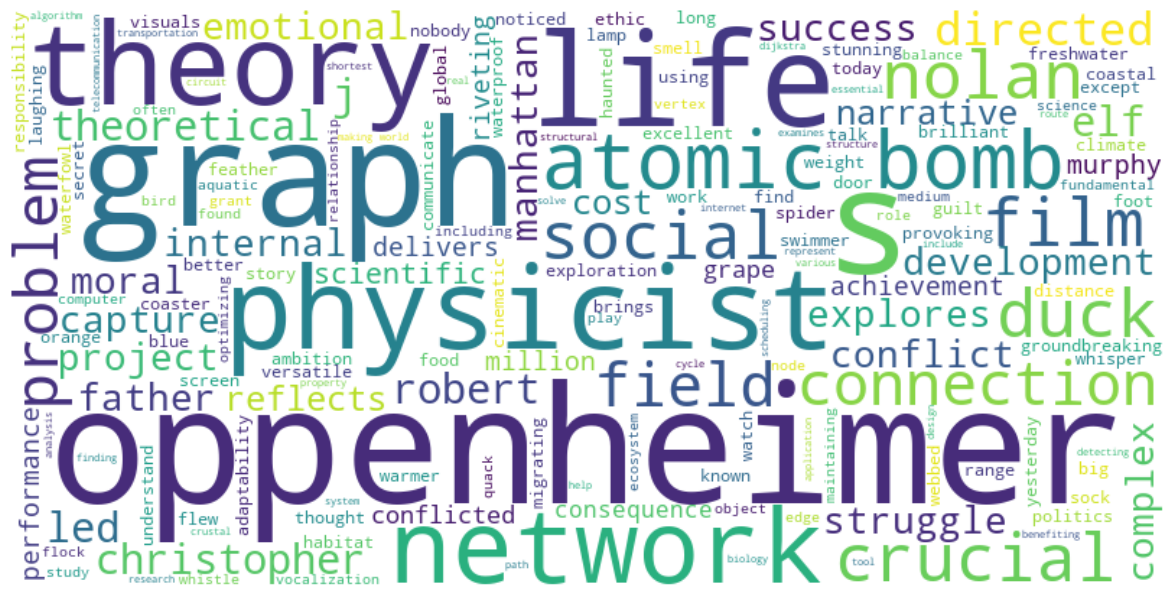

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def visualize_texts(texts_processed):
    # Join all texts into a single string
    all_text = " ".join(texts_processed)

    # Create a WordCloud object
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=200
    ).generate(all_text)

    # Display the generated image
    plt.figure(figsize=(15, 7.5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # remove axes
    plt.show()


# Call the function to visualize
visualize_texts(texts_processed)


## Calculate cosine similarities using TFIDF

Calculate the TFIDF score and cosine similarity between the texts. You may use gensim, write your own script using numpy or use other module. Output the result as a matrix $n\times n$ of cosine similarity scores (where $n$ is the length of texts list).

**Extra credit**: use word2vec word embeddings in vector spaces to get better TFIDF scores by representing each word as a vector.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def calculate_tfidf(texts_processed):

    vectorizer = TfidfVectorizer()

    tfidf_matrix = vectorizer.fit_transform(texts_processed)

    cosine_matrix = cosine_similarity(tfidf_matrix)

    return cosine_matrix

cosine_matrix = calculate_tfidf(texts_processed)
print(cosine_matrix)


[[1.         0.43097756 0.34144056 0.27343667 0.01552764 0.06413209
  0.09123337 0.04334338 0.03900416 0.0809859 ]
 [0.43097756 1.         0.36180253 0.26223162 0.01399172 0.07912532
  0.13640501 0.05077216 0.04719571 0.12420133]
 [0.34144056 0.36180253 1.         0.18588064 0.05496929 0.05342601
  0.11032432 0.04931298 0.05702735 0.08761283]
 [0.27343667 0.26223162 0.18588064 1.         0.05410015 0.12864142
  0.09261143 0.07264786 0.05592861 0.07661639]
 [0.01552764 0.01399172 0.05496929 0.05410015 1.         0.06297553
  0.13676751 0.0417122  0.09343788 0.02545041]
 [0.06413209 0.07912532 0.05342601 0.12864142 0.06297553 1.
  0.05851478 0.06126759 0.03328013 0.05458613]
 [0.09123337 0.13640501 0.11032432 0.09261143 0.13676751 0.05851478
  1.         0.08113903 0.11418339 0.08470745]
 [0.04334338 0.05077216 0.04931298 0.07264786 0.0417122  0.06126759
  0.08113903 1.         0.13761057 0.13322405]
 [0.03900416 0.04719571 0.05702735 0.05592861 0.09343788 0.03328013
  0.11418339 0.13761

## Visualize data

Visualize the `cosine_matrix` data using matplotlib. Choose your own method of plotting the scores in a way, that the similarity indeces between texts would be instantly visible. Plot data about texts as well (a couple of first words in the document).

*Hint: remember heat maps, aren't they nice for this task?*

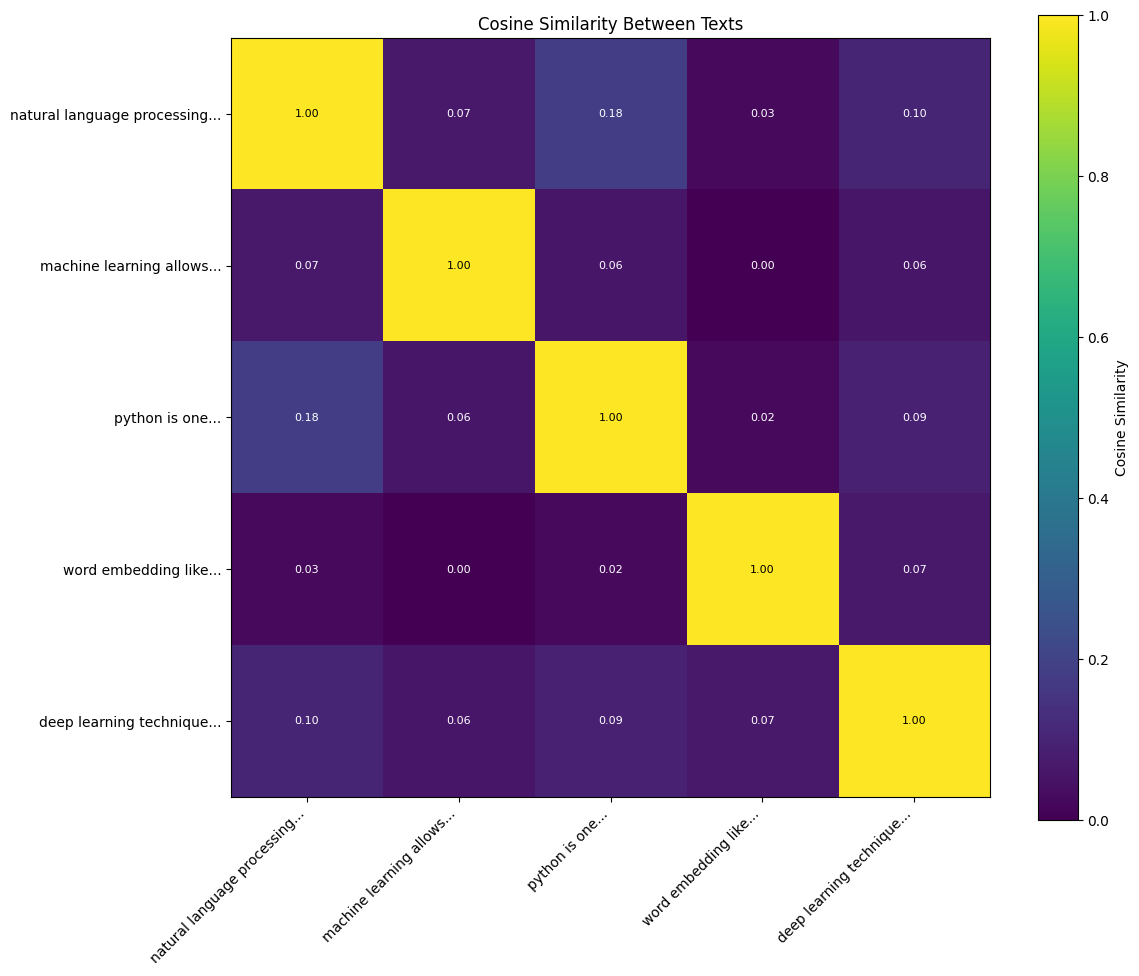

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_data(cosine_matrix, texts_processed):
    """
    Visualize the cosine similarity matrix as a heatmap.
    Labels on axes are the first few words of each text.

    Args:
        cosine_matrix (np.ndarray or list): Cosine similarity matrix.
        texts_processed (list): List of processed texts.

    Returns:
        None
    """
    # Convert to numpy array if needed
    cosine_matrix = np.array(cosine_matrix)
    
    # Create labels using the first 3 words of each text
    labels = [' '.join(text.split()[:3]) + '...' if len(text.split()) > 3 else text for text in texts_processed]

    # Create the figure
    plt.figure(figsize=(12, 10))
    
    # Plot heatmap
    plt.imshow(cosine_matrix, cmap='viridis', interpolation='nearest')
    plt.colorbar(label='Cosine Similarity')
    
    # Set ticks and labels
    plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha='right')
    plt.yticks(ticks=np.arange(len(labels)), labels=labels)
    
    # Add values on the heatmap (optional, can remove if matrix is large)
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, f"{cosine_matrix[i, j]:.2f}", ha='center', va='center', color='white' if cosine_matrix[i,j] < 0.5 else 'black', fontsize=8)

    plt.title('Cosine Similarity Between Texts')
    plt.tight_layout()
    plt.show()


# Call the function
visualize_data(cosine_matrix, texts_processed)


## Analyse your own text using TFIDF (or any other method)

Analyse your own text using previous methods. You may use API fetching to get text data, download texts from Kaggle or use any texts you want. Find cosine similarities and visualize them.

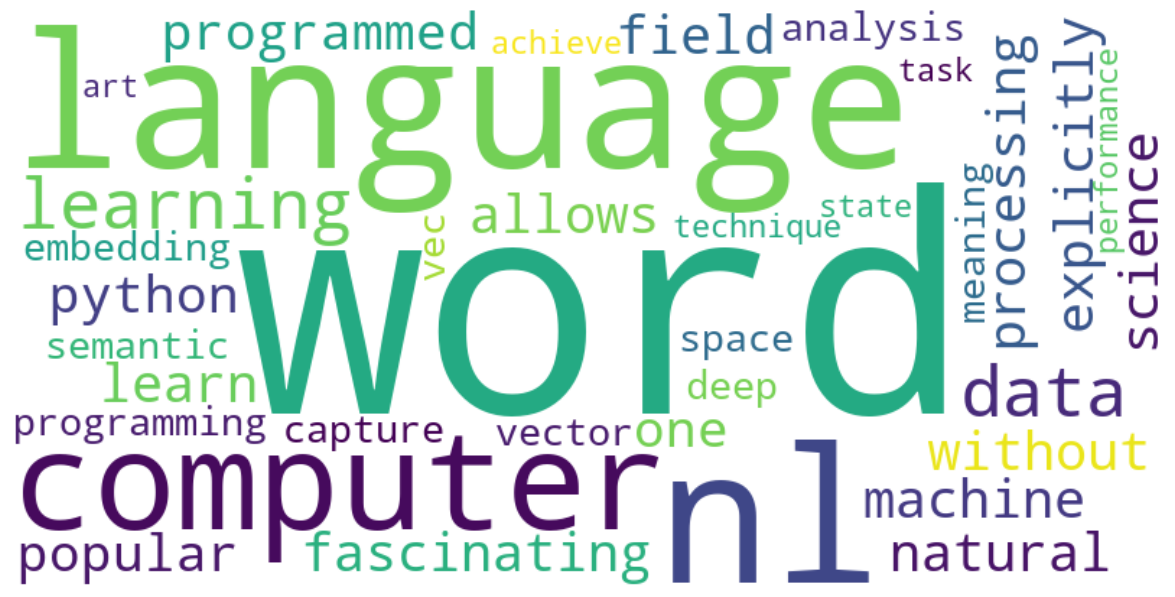

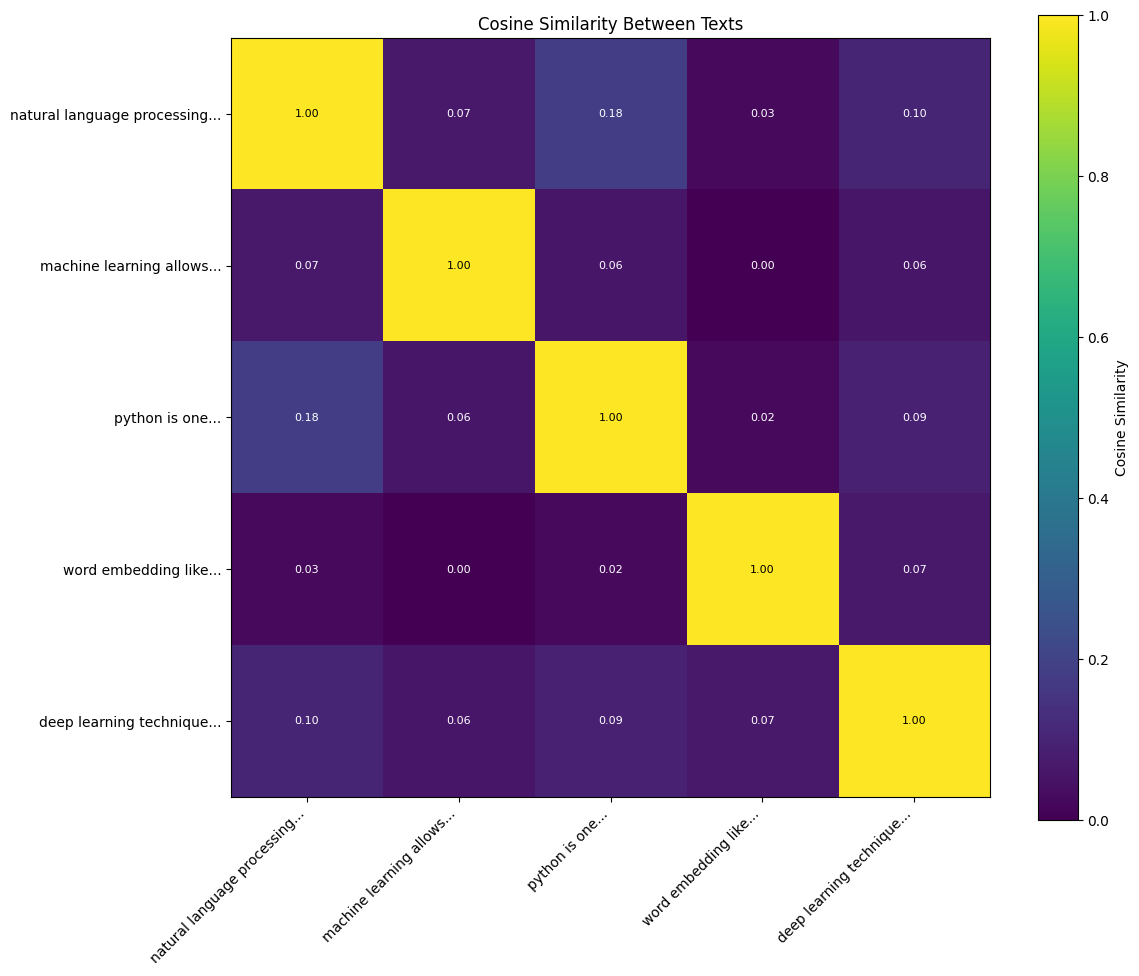

In [18]:
def get_texts():
    texts = [
        "Natural Language Processing (NLP) is a fascinating field of computer science.",
        "Machine learning allows computers to learn from data without being explicitly programmed.",
        "Python is one of the most popular programming languages for data analysis.",
        "Word embeddings like Word2Vec capture semantic meaning of words in vector space.",
        "Deep learning techniques can achieve state-of-the-art performance in NLP tasks."
    ]
    return texts

texts = get_texts()

texts_processed = process_texts(texts)

visualize_texts(texts_processed)

cosine_matrix = calculate_tfidf(texts_processed)

visualize_data(cosine_matrix, texts_processed)
